# Parquet and Polar Processing of EMS Dispatch Data
This notebook does the data pre-processing and analysis of the ems disptach data. This includes parsing the full dataset and saving it as a parquet file. From there it filters the data further and drops ununused data, sainv it as a significantly smaller parquet datafile.

## Imports

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import linregress

## Data Preprocessing

### Loading full dataset
This block takes your path to the raw csv file, parses the csv file (handling edge cases I could find), and saves the data into a parquet file, a data file which has significant storage efficiency gains for large datasets.

In [2]:
# create parquet file for easier handling of large dataset
raw_csv_file_path = "../data/EMS_Incident_Dispatch_Data.csv"
total_parquet_file_path = "../data/ems_dispatch_data_totalset.parquet"

explicit_schema = {
    "CAD_INCIDENT_ID": pl.Int64,
    "INCIDENT_DATETIME": pl.String,                  # Read as string to cast below
    "INITIAL_CALL_TYPE": pl.String,
    "INITIAL_SEVERITY_LEVEL_CODE": pl.Int64,
    "FINAL_CALL_TYPE": pl.String,
    "FINAL_SEVERITY_LEVEL_CODE": pl.Int64,
    "FIRST_ASSIGNMENT_DATETIME": pl.String,
    "VALID_DISPATCH_RSPNS_TIME_INDC": pl.String,
    "DISPATCH_RESPONSE_SECONDS_QY": pl.String,       # Read as string to cast below
    "FIRST_ACTIVATION_DATETIME": pl.String,
    "FIRST_ON_SCENE_DATETIME": pl.String,
    "VALID_INCIDENT_RSPNS_TIME_INDC": pl.String,
    "INCIDENT_RESPONSE_SECONDS_QY": pl.String,       # Read as string to cast below
    "INCIDENT_TRAVEL_TM_SECONDS_QY": pl.String,      # Read as string to cast below
    "FIRST_TO_HOSP_DATETIME": pl.String,
    "FIRST_HOSP_ARRIVAL_DATETIME": pl.String,
    "INCIDENT_CLOSE_DATETIME": pl.String,
    "HELD_INDICATOR": pl.String,
    "INCIDENT_DISPOSITION_CODE": pl.String,
    "BOROUGH": pl.String,
    "INCIDENT_DISPATCH_AREA": pl.String,
    "ZIPCODE": pl.String,                            
    "POLICEPRECINCT": pl.Int64,
    "CITYCOUNCILDISTRICT": pl.Int64,
    "COMMUNITYDISTRICT": pl.Int64,
    "COMMUNITYSCHOOLDISTRICT": pl.Int64,
    "CONGRESSIONALDISTRICT": pl.Int64,
    "REOPEN_INDICATOR": pl.String,
    "SPECIAL_EVENT_INDICATOR": pl.String,
    "STANDBY_INDICATOR": pl.String,
    "TRANSFER_INDICATOR": pl.String
}

cols_to_float = [
    "DISPATCH_RESPONSE_SECONDS_QY",
    "INCIDENT_RESPONSE_SECONDS_QY",
    "INCIDENT_TRAVEL_TM_SECONDS_QY"
]

cols_to_datetime = [
    "INCIDENT_DATETIME", 
    "FIRST_ASSIGNMENT_DATETIME", 
    "FIRST_ACTIVATION_DATETIME",
    "FIRST_ON_SCENE_DATETIME", 
    "FIRST_TO_HOSP_DATETIME", 
    "FIRST_HOSP_ARRIVAL_DATETIME",
    "INCIDENT_CLOSE_DATETIME"
]

print("Starting conversion of raw csv data file to parquet file. May take a minute or two...")
# Use lazy data streaming to avoid loading entire file into memory
pl.scan_csv(raw_csv_file_path, schema=explicit_schema)\
    .with_columns(
        # Strip commas and cast to Float64
        pl.col(cols_to_float).str.replace_all(",", "").cast(pl.Float64),
        # Cast strings to Datetime. 
        # strict=False safely turns unparseable/blank dates into Nulls instead of crashing
        pl.col(cols_to_datetime).str.to_datetime(format="%m/%d/%Y %I:%M:%S %p", strict=False))\
    .sink_parquet(total_parquet_file_path)
print(f"Success! Data saved as parquet file to {total_parquet_file_path}")

print("--- Data Validation Starting ---")
csv_lazy = pl.scan_csv(raw_csv_file_path, ignore_errors=True)
parquet_lazy = pl.scan_parquet(total_parquet_file_path)

print("Counting rows in both files...")
csv_count = csv_lazy.select(pl.len()).collect().item()
parquet_count = parquet_lazy.select(pl.len()).collect().item()

print(f"CSV Rows:     {csv_count:,}")
print(f"Parquet Rows: {parquet_count:,}")

if csv_count == parquet_count:
    print("Success! Row counts match perfectly! No data was lost.")
else:
    print("Warning: Row counts differ.")

Starting conversion of raw csv data file to parquet file. May take a minute or two...
Success! Data saved as parquet file to ../data/ems_dispatch_data_totalset.parquet
--- Data Validation Starting ---
Counting rows in both files...
CSV Rows:     28,697,378
Parquet Rows: 28,697,378
Success! Row counts match perfectly! No data was lost.


### Filtering full dataset
This block takes a parquet file of the total dataset (such as the one generated above) and does some basic data validation and filtering . In addition, it drops columns we do not intend to use in this analysis. This results in a significantly cleaner (and smaller) dataset to work with.

In [3]:
# filter the total dataset and save it as filtered data
total_parquet_file_path = "../data/ems_dispatch_data_totalset.parquet"
filtered_parquet_file_path = "../data/ems_dispatch_data_filtered.parquet"

location_columns = [
    "BOROUGH", "INCIDENT_DISPATCH_AREA", "ZIPCODE", "POLICEPRECINCT", 
    "CITYCOUNCILDISTRICT", "COMMUNITYDISTRICT", "COMMUNITYSCHOOLDISTRICT", 
    "CONGRESSIONALDISTRICT"
]

columns_to_drop = [
    "CAD_INCIDENT_ID", "INITIAL_CALL_TYPE", "FINAL_CALL_TYPE", 
    "FIRST_ASSIGNMENT_DATETIME", "FIRST_ACTIVATION_DATETIME", 
    "FIRST_ON_SCENE_DATETIME", "FIRST_TO_HOSP_DATETIME", 
    "FIRST_HOSP_ARRIVAL_DATETIME", "INCIDENT_CLOSE_DATETIME", 
    "HELD_INDICATOR", "INCIDENT_DISPOSITION_CODE"
]

print("Applying filters to the dataset...")
(
    pl.scan_parquet(total_parquet_file_path)\

    # --- Base Validity Filters ---
    .filter(
        (pl.col("VALID_INCIDENT_RSPNS_TIME_INDC") == "Y") & 
        (pl.col("INCIDENT_RESPONSE_SECONDS_QY") > 0)
    )\
    
    # --- Location Filter ---
    # any_horizontal checks if AT LEAST ONE of the columns in the list is not null for that row
    .filter(
        pl.any_horizontal(pl.col(location_columns).is_not_null())
    )\
    
    # --- Handle Missing Severities ---
    # This fills nulls in INITIAL with the value from FINAL, and vice versa. 
    # If both are null, they both remain null.
    .with_columns(
        pl.col("INITIAL_SEVERITY_LEVEL_CODE").fill_null(pl.col("FINAL_SEVERITY_LEVEL_CODE")),
        pl.col("FINAL_SEVERITY_LEVEL_CODE").fill_null(pl.col("INITIAL_SEVERITY_LEVEL_CODE"))
    )\
    
    # --- Severity Range Filter ---
    # Ensure both are severities are between 1 and 8.
    # If a row had both severities as null, the row will be dropped.
    .filter(
        pl.col("INITIAL_SEVERITY_LEVEL_CODE").is_between(1, 7) &
        pl.col("FINAL_SEVERITY_LEVEL_CODE").is_between(1, 7)
    )\
    
    # --- Drop Unused Columns ---
    # Removing these trims down the file size significantly
    .drop(columns_to_drop)\

    # --- Add Additional Data Columns ---
    # Adds date and hour columnns for later grouping
    .with_columns(
        pl.col("INCIDENT_DATETIME").dt.date().alias("INCIDENT_DATE"),
        pl.col("INCIDENT_DATETIME").dt.hour().alias("INCIDENT_HOUR")
    )\
    
    # --- STEP F: Save the Final Analytical Dataset ---
    .sink_parquet(filtered_parquet_file_path)
)

print(f"Success! Fully cleaned and filtered data saved to: {filtered_parquet_file_path}")

total_dataset_count = (
    pl.scan_parquet(total_parquet_file_path)
    .select(pl.len())
    .collect()
    .item()
)

filtered_count = (
    pl.scan_parquet(filtered_parquet_file_path)
    .select(pl.len())
    .collect()
    .item()
)

dropped_count = total_dataset_count - filtered_count

print(f"Total Dataset Rows:  {total_dataset_count}")
print(f"Filtered Dataset Rows:  {filtered_count}")
print(f"Rows Dropped:   {dropped_count}")

Applying filters to the dataset...
Success! Fully cleaned and filtered data saved to: ../data/ems_dispatch_data_filtered.parquet
Total Dataset Rows:  28697378
Filtered Dataset Rows:  27287154
Rows Dropped:   1410224


## Data Analysis
This block will do most of the data analysis intended to do within the project. A common value used here is the 90th percentile response time. We use this value because it is [widely used as a metric to assess EMS performance](https://www.ems.gov/assets/EMS_Performance_Measures_2009.pdf)

### Assumption 1: High Severity Response Time Increases with Volume of Low Severity Calls
The first thing to validate is that the response time to high severity calls actually does increase as the volume of low severity calls increases.  The block of code below gets the volume and 90th percentile response time for each severity level of calls for any given hour. From there it creates a correlation matrix, findind the correlation of call volume for a given severity and its correlation with response time for a given severity.

#### Generating the Hourly Features Dataset
Before we can prove our assumptions, we need to reshape our raw data. The goal here is to aggregate millions of individual 911 calls into an hourly summary. 

For every single hour in the dataset, we will calculate:
1. The Total Volume of calls for each severity level (1-7).
2. The 90th Percentile Response Time for each severity level (1-7).

Once we fill this data into a single table, we will save it as a `.parquet` file.

In [4]:
filtered_parquet_file_path = "../data/ems_dispatch_data_filtered.parquet"
hourly_features_path = "../data/hourly_features_joined.parquet"

# read fitered parquet data file 
lf = pl.scan_parquet(filtered_parquet_file_path)

print("Getting volume and 90th Percentile Response Time per Severity")
hour_and_severity_df = (
    lf.group_by(["INCIDENT_DATE", "INCIDENT_HOUR", "INITIAL_SEVERITY_LEVEL_CODE"])
    .agg(
        pl.len().alias("SEVERITY_VOLUME"),
        pl.col("INCIDENT_RESPONSE_SECONDS_QY").quantile(0.90).alias("90TH_PERC_RESP_TIME")
    )
    .collect()
)

print("Grouping data from each hour to have the volume and repsonse time to calls gropued by severity...")
# Create columns for each severities volume, filling nulls (no calls of that severity) with 0,
vol_df = hour_and_severity_df.pivot(
    values="SEVERITY_VOLUME",
    index=["INCIDENT_DATE", "INCIDENT_HOUR"],
    on="INITIAL_SEVERITY_LEVEL_CODE"
).fill_null(0)
# Rename severity code columns so that there is not name clash later
vol_rename_map = {str(i): f"INITIAL_SEVERITY_LEVEL_{i}_VOLUME" for i in range(1, 8)}
vol_df = vol_df.rename(vol_rename_map)

# Create columns for each severtieis response time, NOT filling nulls
resp_df = hour_and_severity_df.pivot(
    values="90TH_PERC_RESP_TIME",
    index=["INCIDENT_DATE", "INCIDENT_HOUR"],
    on="INITIAL_SEVERITY_LEVEL_CODE"
)
# Rename severity code columns so that there is not name clash later
resp_rename_map = {str(i): f"INITIAL_SEVERITY_LEVEL_{i}_90TH_PERC_RESP_TIME" for i in range(1, 8)}
resp_df = resp_df.rename(resp_rename_map)

# join columns so that we have response time and call volume of each severity level for a given hour
hourly_features_df = vol_df.join(resp_df, on=["INCIDENT_DATE", "INCIDENT_HOUR"])
print(hourly_features_df.head(10))

Getting volume and 90th Percentile Response Time per Severity
Grouping data from each hour to have the volume and repsonse time to calls gropued by severity...
shape: (10, 16)
┌──────────────┬──────────────┬──────────────┬─────────────┬───┬─────────────┬─────────────┬─────────────┬─────────────┐
│ INCIDENT_DAT ┆ INCIDENT_HOU ┆ INITIAL_SEVE ┆ INITIAL_SEV ┆ … ┆ INITIAL_SEV ┆ INITIAL_SEV ┆ INITIAL_SEV ┆ INITIAL_SEV │
│ E            ┆ R            ┆ RITY_LEVEL_1 ┆ ERITY_LEVEL ┆   ┆ ERITY_LEVEL ┆ ERITY_LEVEL ┆ ERITY_LEVEL ┆ ERITY_LEVEL │
│ ---          ┆ ---          ┆ _VOLUM…      ┆ _7_VOLUM…   ┆   ┆ _2_90TH_…   ┆ _4_90TH_…   ┆ _3_90TH_…   ┆ _6_90TH_…   │
│ date         ┆ i8           ┆ ---          ┆ ---         ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│              ┆              ┆ u32          ┆ u32         ┆   ┆ f64         ┆ f64         ┆ f64         ┆ f64         │
╞══════════════╪══════════════╪══════════════╪═════════════╪═══╪═════════════╪═════════════╪══════

In [5]:
# Save hourly_features dataset to parquet file
hourly_features_df.write_parquet(hourly_features_path)
print(f"Hourly features successfully saved to: {hourly_features_path}")

Hourly features successfully saved to: ../data/hourly_features_joined.parquet


#### Calculating correlations betwen call volume and responsse time by severity
Now that we have our hourly features, we need to validate that the response time for high-severity calls increases as the volume of low-severity calls increases. 

The block below loads our aggregated hourly data and generates a 7x7 Cross-Correlation Matrix. By cross-referencing the volume of every severity against the response time of every severity, we can find how call volume fore a given severity is correlated with response time for calls of a given severity.

We save the output matrix to a CSV.

In [6]:
hourly_features_path = "../data/hourly_features_joined.parquet"
matrix_csv_path = "../data/correlation_matrix.csv"

hourly_features_df = pl.read_parquet(hourly_features_path)

print("Creating correlation matrix of correlation between volume of calls of each severity and response time of each severity...")
# Create 7x7 correlation matrix
matrix_rows= []
for sev_vol in range(1,8):
    # Label Row to show which severitiy's call volume is 90th percentil response time being correlated to
    row_data = {"Call Volume": f"Severity {sev_vol}"}
    for sev_resp_time in range(1, 8):
        vol_col = f"INITIAL_SEVERITY_LEVEL_{sev_vol}_VOLUME"
        resp_col = f"INITIAL_SEVERITY_LEVEL_{sev_resp_time}_90TH_PERC_RESP_TIME"

        corr_val = (
            hourly_features_df.select([pl.col(vol_col), pl.col(resp_col)])
            .drop_nulls()
            .select(pl.corr(vol_col, resp_col))
            .item()
        )
        row_data[f"Severity {sev_resp_time} Response Time"] = corr_val if corr_val is not None else None

    matrix_rows.append(row_data)

correlation_matrix = pl.DataFrame(matrix_rows)
print(correlation_matrix)

Creating correlation matrix of correlation between volume of calls of each severity and response time of each severity...
shape: (7, 8)
┌─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ Call Volume ┆ Severity 1   ┆ Severity 2   ┆ Severity 3   ┆ Severity 4   ┆ Severity 5   ┆ Severity 6   ┆ Severity 7   │
│ ---         ┆ Response     ┆ Response     ┆ Response     ┆ Response     ┆ Response     ┆ Response     ┆ Response     │
│ str         ┆ Time         ┆ Time         ┆ Time         ┆ Time         ┆ Time         ┆ Time         ┆ Time         │
│             ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│             ┆ f64          ┆ f64          ┆ f64          ┆ f64          ┆ f64          ┆ f64          ┆ f64          │
╞═════════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ Severity 1  ┆ 0

In [7]:
# Save matrix to a csv file
correlation_matrix.write_csv(matrix_csv_path)
print(f"\nMatrix successfully saved to: {matrix_csv_path}")


Matrix successfully saved to: ../data/correlation_matrix.csv


Generate a heatmap visualization of the correlation matrix for easier interpretation.

Generating heatmap visualization of correlation matrix...


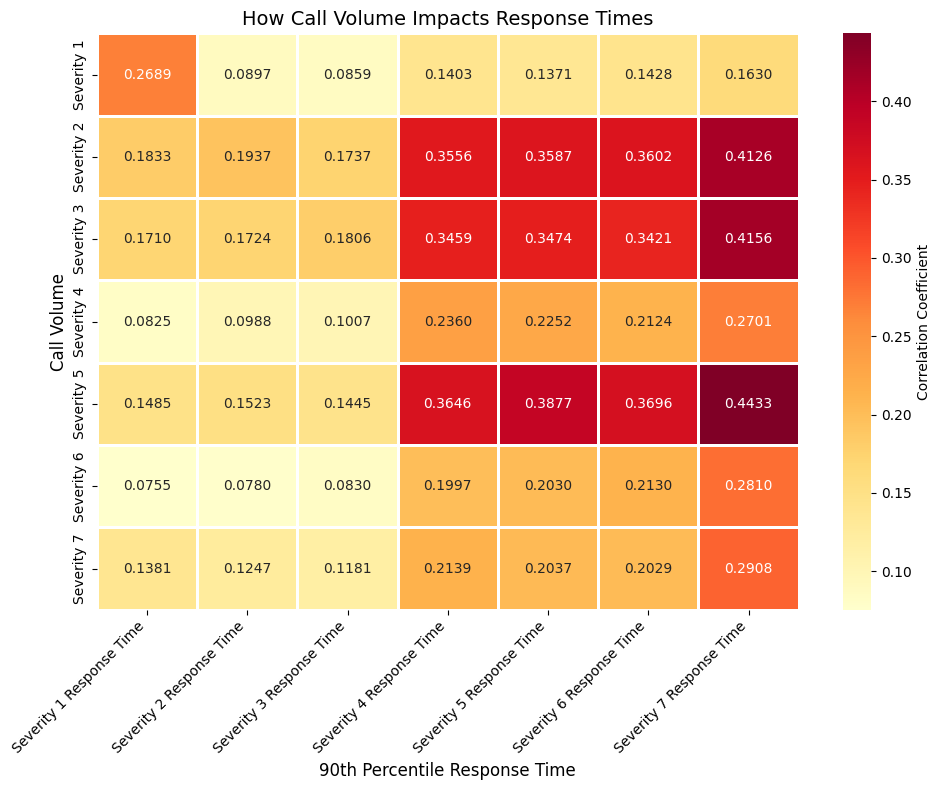

In [8]:
matrix_csv_path = "../data/correlation_matrix.csv"

# Read in correlation amtrix data from saved csv file
pandas_matrix = pd.read_csv(matrix_csv_path, index_col=0)

print("Generating heatmap visualization of correlation matrix...")
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
sns.heatmap(
    pandas_matrix, 
    annot=True,              
    fmt=".4f",               
    cmap="YlOrRd",           
    linewidths=1,            
    cbar_kws={'label': 'Correlation Coefficient'},
    ax=ax
)

# plot labels
ax.set_title("How Call Volume Impacts Response Times", fontsize=14)
ax.set_xlabel("90th Percentile Response Time", fontsize=12)
ax.set_ylabel("Call Volume", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()

plt.show()


In [9]:
# save generated heatmap image
corr_heatmap_image_path = "../figs/correlation_heatmap.png"

fig.savefig(corr_heatmap_image_path, dpi=300) 

print(f"Heatmap successfully saved to: {corr_heatmap_image_path}")

Heatmap successfully saved to: ../figs/correlation_heatmap.png


### Results
A few take-aways can be made from the data above.

First and foremost is the confirmation of our baseline assumption - there is a positive correlation between the volume of low-severity calls and high-severity response times. However, something interesting can be seen in addition to that; there is a greater imnpact on reponse time of LOW severity calls due to the volume of HIGH severity calls. 

While at first, that might seem counter to our approach, this actually confirms the need for our approach. Dispatchers are currently triaging the calls they recieve themselves. By diverting low-acuity calls outside of the EMS system, both low AND high sverity calls can get the attention they need sooner, as well as reducing the cognitive load on dispatchers.

## Data Regression Modeling

While correlation proves that a relationship exists, it does not give us the exact numbers needed to build an interactive tool. We need to know how many seconds of wait time are added to a specific severity level for every single call of another severity level.

We will run an Ordinary Least Squares (OLS) regression on our `hourly_features` dataset; we are extracting the regression slope for every possible combination of call severities. 

In [10]:
hourly_features_path = "../data/hourly_features_joined.parquet"
regression_csv_path = "../data/regression_matrix.csv"

hourly_features_df = pl.read_parquet(hourly_features_path)

print("Calculating the 7x7 Regression (Slope) Matrix...")

matrix_rows = []
for sev_vol in range(1, 8):

    row_data = {"Per Added Call of Severity": f"Severity {sev_vol}"}
    
    for sev_resp_time in range(1, 8):
        vol_col = f"INITIAL_SEVERITY_LEVEL_{sev_vol}_VOLUME"
        resp_col = f"INITIAL_SEVERITY_LEVEL_{sev_resp_time}_90TH_PERC_RESP_TIME"

        valid_data = hourly_features_df.select([pl.col(vol_col), pl.col(resp_col)]).drop_nulls()
        
        if valid_data.height > 1:
            x = valid_data[vol_col].to_numpy()
            y = valid_data[resp_col].to_numpy()
            
            slope, intercept, r_value, p_value, std_err = linregress(x, y)

            row_data[f"Sev {sev_resp_time} Resp Time Increase (sec)"] = slope
        else:
            row_data[f"Sev {sev_resp_time} Resp Time Increase (sec)"] = None

    matrix_rows.append(row_data)

regression_matrix = pl.DataFrame(matrix_rows)

print("\n--- Regression Slope Matrix: Seconds of Response Time Added Per Call ---")
print(regression_matrix)

Calculating the 7x7 Regression (Slope) Matrix...

--- Regression Slope Matrix: Seconds of Response Time Added Per Call ---
shape: (7, 8)
┌──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬─────────────┐
│ Per Added    ┆ Sev 1 Resp   ┆ Sev 2 Resp   ┆ Sev 3 Resp   ┆ Sev 4 Resp   ┆ Sev 5 Resp   ┆ Sev 6 Resp   ┆ Sev 7 Resp  │
│ Call of      ┆ Time         ┆ Time         ┆ Time         ┆ Time         ┆ Time         ┆ Time         ┆ Time        │
│ Severity     ┆ Increase     ┆ Increase     ┆ Increase     ┆ Increase     ┆ Increase     ┆ Increase     ┆ Increase    │
│ ---          ┆ (sec)        ┆ (sec)        ┆ (sec)        ┆ (sec)        ┆ (sec)        ┆ (sec)        ┆ (sec)       │
│ str          ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---         │
│              ┆ f64          ┆ f64          ┆ f64          ┆ f64          ┆ f64          ┆ f64          ┆ f64         │
╞══════════════╪

In [11]:
# Save regression matrix to csv file
regression_matrix.write_csv(regression_csv_path)
print(f"\nRegression matrix successfully saved to: {regression_csv_path}")


Regression matrix successfully saved to: ../data/regression_matrix.csv


### Visualization

To make this understandable at a glance, we will visualize the matrix as a heatmap

Generating heatmap...


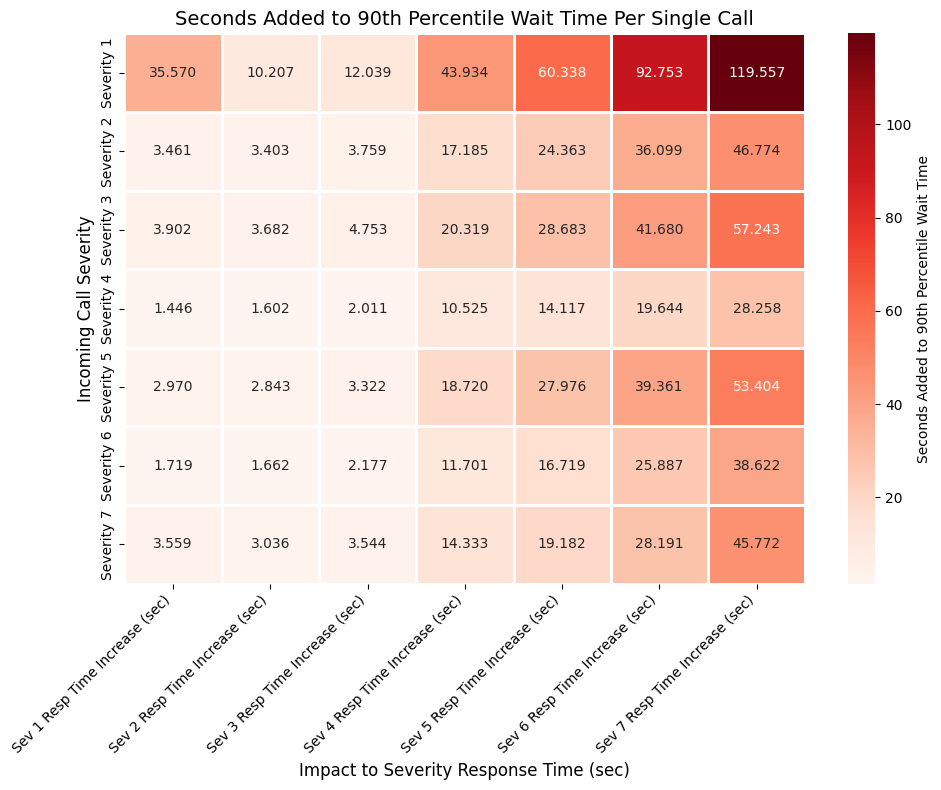

In [12]:
regression_csv_path = "../data/regression_matrix.csv"
regression_heatmap_path = "../figs/regression_heatmap.png"

pandas_reg_matrix = pd.read_csv(regression_csv_path, index_col=0)

print("Generating heatmap...")
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    pandas_reg_matrix, 
    annot=True,              
    fmt=".3f",               
    cmap="Reds",           
    linewidths=1,            
    cbar_kws={'label': 'Seconds Added to 90th Percentile Wait Time'},
    ax=ax  
)

ax.set_title("Seconds Added to 90th Percentile Wait Time Per Single Call", fontsize=14)
ax.set_xlabel("Impact to Severity Response Time (sec)", fontsize=12)
ax.set_ylabel("Incoming Call Severity", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()

plt.show()

In [13]:
# Save generated heatmap image
fig.savefig(regression_heatmap_path, dpi=300) 
print(f"Regression heatmap successfully saved to: {regression_heatmap_path}")

Regression heatmap successfully saved to: ../figs/regression_heatmap.png
